In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Dataset
df = pd.read_csv("House Price Prediction Dataset.csv")
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [5]:
# Important Features
X = df[['Area', 'Bedrooms', 'Bathrooms',
        'Floors', 'YearBuilt',
        'Location', 'Condition', 'Garage']]

y = df['Price']

In [6]:
# Categorical columns
encoder = LabelEncoder()

X['Location'] = encoder.fit_transform(X['Location'])
X['Condition'] = encoder.fit_transform(X['Condition'])
X['Garage'] = encoder.fit_transform(X['Garage'])

In [7]:
# Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Predict Prices
y_pred = model.predict(X_test)

In [12]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


Mean Absolute Error: 244419.99901363705
RMSE: 280587.6374016649


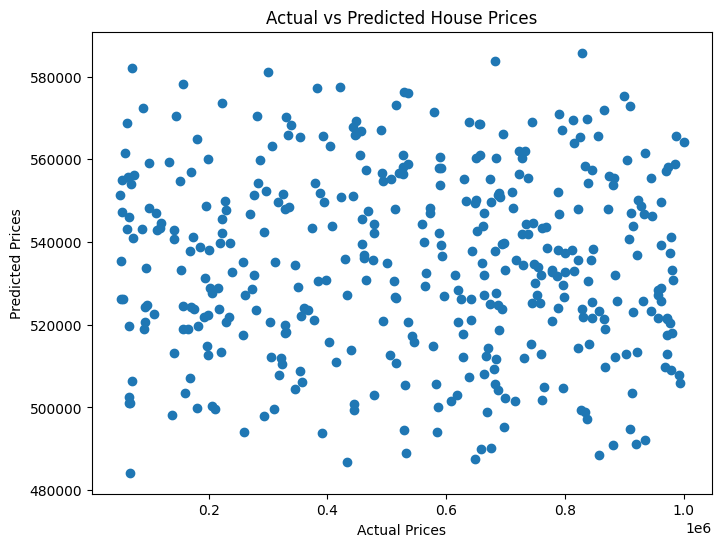

In [13]:
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [16]:
# Better Model (Higher Accuracy)
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [17]:
# Gradient Boosting
gb_mae = mean_absolute_error(y_test, gb_pred)
print("Gradient Boosting MAE:", gb_mae)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 244898.61393757886
Gradient Boosting RMSE: 283589.96870782383


In [18]:
# Comparison Table 
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'MAE': [mae, gb_mae],
    'RMSE': [rmse, gb_rmse]
})

print(comparison)

               Model            MAE           RMSE
0  Linear Regression  244419.999014  280587.637402
1  Gradient Boosting  244898.613938  283589.968708


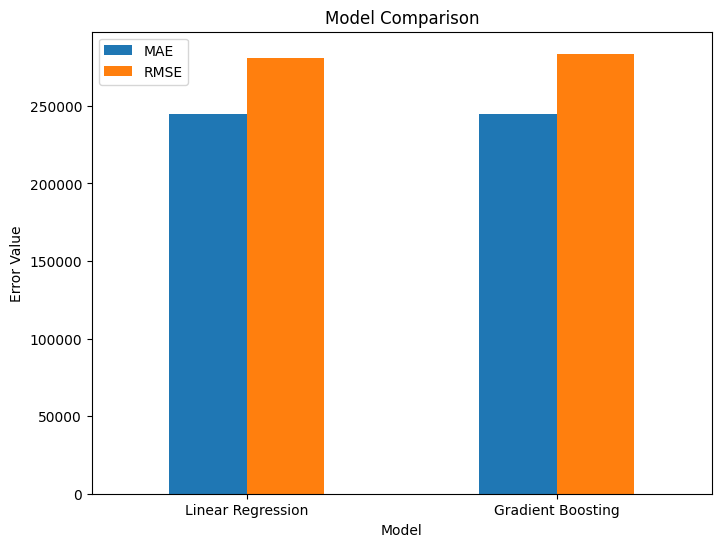

In [19]:
# Visualize Comparison Table
comparison.set_index('Model').plot(kind='bar', figsize=(8,6))

plt.title("Model Comparison")
plt.ylabel("Error Value")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()